In [9]:
import json
import networkx as nx
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from networkx.readwrite import json_graph
from pathlib import Path
import os
import sys
import subprocess
repo_root = Path(subprocess.check_output(
    ['git', 'rev-parse', '--show-toplevel'], text=True
).strip())
sys.path.insert(0, str(repo_root))

from pipeline.metrics import moran, gini, frey, dissimilarity, assortativity, property_sum, half_edge
from pipeline.metrics import make_adj_weights

In [10]:
graph_dir = repo_root / "data/processed/dual_graphs"
cluster_csv = repo_root / "experiments/h4_t3_observed_diffusion/data/auto_cluster_tracts.csv"
geography = "max_city"

CITIES = {
    "chicago":      {"cbsa": 16980,   "max_city": 1714000},
    "philadelphia": {"cbsa": 37980,   "max_city": 4260000},
}


YEARS = [1980, 1990, 2000, 2010, 2020]

# Load city-wide graphs: graphs[(city, year)] -> nx.Graph
graphs = {}
for city, cfg in CITIES.items():
    for year in YEARS:
        path = graph_dir / str(year) / f"tracts_in_{geography}_{cfg[geography]}_{year}_2020_vintage_connected.json"
        with open(path) as f:
            graphs[(city, year)] = nx.adjacency_graph(json.load(f))

# Build cluster membership lookup from the CSV
# cluster_nodes[(city, year, cluster_title)] -> set of node ids in the city-wide graph
df = pd.read_csv(cluster_csv)

cluster_nodes = {}
for city, cfg in CITIES.items():
    city_df = df[df["cbsa"] == cfg["cbsa"]]
    for year in YEARS:
        G = graphs[(city, year)]
        gisjoin_to_nodeid = {data["GISJOIN"]: node for node, data in G.nodes(data=True)}
        year_df = city_df[city_df["year"] == year]
        for cluster_title, group in year_df.groupby("cluster_title"):
            node_ids = set()
            for gisjoin in group["gisjoin"]:
                if gisjoin in gisjoin_to_nodeid:
                    node_ids.add(gisjoin_to_nodeid[gisjoin])
            cluster_nodes[(city, year, cluster_title)] = node_ids

# Example: subgraph of Chicago South Side 1980 within the city-wide graph
cluster_nodes


{('chicago', 1980, 'Chicago, Austin'): {56,
  63,
  64,
  75,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  97,
  98,
  125,
  126,
  136,
  139,
  210,
  273,
  279,
  280,
  281,
  282,
  283,
  284,
  285,
  286,
  318,
  334,
  335,
  336,
  337,
  338,
  339,
  340,
  341,
  342,
  343,
  344,
  345,
  346,
  347,
  348,
  349,
  350,
  403,
  406,
  408,
  430,
  438,
  441,
  468,
  470,
  474,
  475,
  494,
  495,
  496,
  529,
  530,
  533,
  553,
  554,
  555,
  568,
  602,
  603,
  604,
  605,
  606,
  619,
  620,
  677,
  679,
  682,
  683,
  684,
  685,
  687,
  688,
  711,
  712,
  713,
  714,
  715,
  717,
  752,
  753,
  755,
  757,
  758,
  762,
  763,
  764,
  768,
  770,
  781,
  782,
  787,
  788,
  789,
  790,
  792,
  793,
  794,
  796,
  797,
  798,
  799,
  805,
  806,
  807,
  811,
  813,
  814,
  842,
  843,
  851,
  864},
 ('chicago', 1980, 'Chicago, South Side'): {2,
  3,
  6,
  8,
  9,
  10,
  11,
  23,
  41,
  44,
  45,
  46,
  47,
  51,
  52,
  53,
  

In [11]:
nodes = cluster_nodes[("chicago", 1980, "Chicago, South Side")]
graph = graphs[("chicago", 1980)]

top_sum = 0

shares = np.array([
    graph.nodes[node]["BLACK"] / graph.nodes[node]["TOTPOP"]
    for node in graph.nodes()
    ])

shares -= shares.mean()
node_to_i = {node: i for i, node in enumerate(graph.nodes())}

top_sum = 0
bottom_sum = 0
for i, node in enumerate(graph.nodes()):
    bottom_sum += shares[i] ** 2
    if node in nodes:
        for nbr in graph.neighbors(node):
            top_sum += shares[i] * shares[node_to_i[nbr]]
    
local_moran = len(graph) * (top_sum / bottom_sum)
local_moran

np.float64(1490.6555728984147)

In [12]:
def local_moran(graph, cluster_nodes):
    shares = np.array([
        graph.nodes[node]["BLACK"] / graph.nodes[node]["TOTPOP"]
        for node in graph.nodes()
    ])
    shares -= shares.mean()
    node_to_i = {node: i for i, node in enumerate(graph.nodes())}

    top_sum = 0
    bottom_sum = 0
    for i, node in enumerate(graph.nodes()):
        bottom_sum += shares[i] ** 2
        if node in cluster_nodes:
            for nbr in graph.neighbors(node):
                top_sum += shares[i] * shares[node_to_i[nbr]]
    
    return len(graph)/len(graph.edges()) * (top_sum / bottom_sum)

In [13]:
years = [1980, 1990, 2000, 2010, 2020]


In [14]:
years = [1980, 1990, 2000, 2010, 2020]
for year in years:
    graph = graphs[("chicago", year)]
    nodes = cluster_nodes[("chicago", year, "Chicago, Austin")]
    print(f"Year {year}: Local Moran's I = {local_moran(graph, nodes)}")

Year 1980: Local Moran's I = 0.2991972954161539
Year 1990: Local Moran's I = 0.2881465515744813
Year 2000: Local Moran's I = 0.26977678630984475
Year 2010: Local Moran's I = 0.2499182784911602
Year 2020: Local Moran's I = 0.23434823169649158


In [15]:
years = [1980, 1990, 2000, 2010, 2020]
for year in years:
    graph = graphs[("philadelphia", year)]
    nodes = cluster_nodes[("philadelphia", year, "Philadelphia, Germantown")]
    print(f"Year {year}: Local Moran's I = {local_moran(graph, nodes)}")

Year 1980: Local Moran's I = 0.7083858525287736
Year 1990: Local Moran's I = 0.7243457262720506
Year 2000: Local Moran's I = 0.6433573918254187
Year 2010: Local Moran's I = 0.5557738158822947
Year 2020: Local Moran's I = 0.6034756152066085


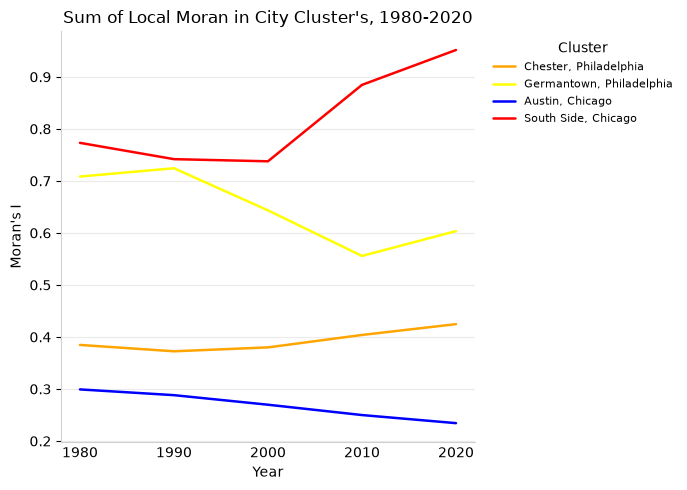

In [16]:
years = [1980, 1990, 2000, 2010, 2020]

fig, ax = plt.subplots(figsize=(7, 5))
chester = []
germantown = []
austin = []
southside = []

for year in years:
    graph = graphs[("philadelphia", year)]
    nodes = cluster_nodes[("philadelphia", year, "Philadelphia, Chester")]
    chester.append(local_moran(graph, nodes))

for year in years:
    graph = graphs[("philadelphia", year)]
    nodes = cluster_nodes[("philadelphia", year, "Philadelphia, Germantown")]
    germantown.append(local_moran(graph, nodes))

for year in years:
    graph = graphs[("chicago", year)]
    nodes = cluster_nodes[("chicago", year, "Chicago, South Side")]
    southside.append(local_moran(graph, nodes))

for year in years:
    graph = graphs[("chicago", year)]
    nodes = cluster_nodes[("chicago", year, "Chicago, Austin")]
    austin.append(local_moran(graph, nodes))

ax.plot(years, chester, color="orange", linewidth=1.8,
    solid_capstyle="round", label="Chester, Philadelphia")
ax.plot(years, germantown, color="yellow", linewidth=1.8,
    solid_capstyle="round", label="Germantown, Philadelphia")
ax.plot(years, austin, color="blue", linewidth=1.8,
    solid_capstyle="round", label="Austin, Chicago")
ax.plot(years, southside, color="red", linewidth=1.8,
    solid_capstyle="round", label="South Side, Chicago")
    
ax.set_xticks(years)
ax.set_xlabel("Year")
ax.set_ylabel("Moran's I")
ax.xaxis.set_tick_params(length=0)
ax.grid(axis="y", color="#ebebeb", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#d0d0d0")
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left",
        fontsize=8, frameon=False)
ax.set_title(f"Sum of Local Moran in City Cluster's, 1980-2020")
plt.tight_layout()
fig.savefig(f"../figures/Local Moran Sum in Cluster's in {geography}", dpi=150, bbox_inches="tight")
plt.show()